Epoch 1/10
1757/1757 - 6s - loss: 2.4514e-04 - 6s/epoch - 3ms/step
Epoch 2/10
1757/1757 - 4s - loss: 1.1637e-05 - 4s/epoch - 2ms/step
Epoch 3/10
1757/1757 - 4s - loss: 1.2183e-05 - 4s/epoch - 2ms/step
Epoch 4/10
1757/1757 - 4s - loss: 9.9392e-06 - 4s/epoch - 3ms/step
Epoch 5/10
1757/1757 - 4s - loss: 1.1073e-05 - 4s/epoch - 2ms/step
Epoch 6/10
1757/1757 - 4s - loss: 6.9185e-06 - 4s/epoch - 2ms/step
Epoch 7/10
1757/1757 - 4s - loss: 6.4501e-06 - 4s/epoch - 2ms/step
Epoch 8/10
1757/1757 - 4s - loss: 7.4829e-06 - 4s/epoch - 2ms/step
Epoch 9/10
1757/1757 - 4s - loss: 6.3895e-06 - 4s/epoch - 2ms/step
Epoch 10/10
1757/1757 - 4s - loss: 6.8959e-06 - 4s/epoch - 2ms/step
440/440 [==============================] - 1s 1ms/step
Train Score: 574.13 RMSE
Test Score: 198.67 RMSE


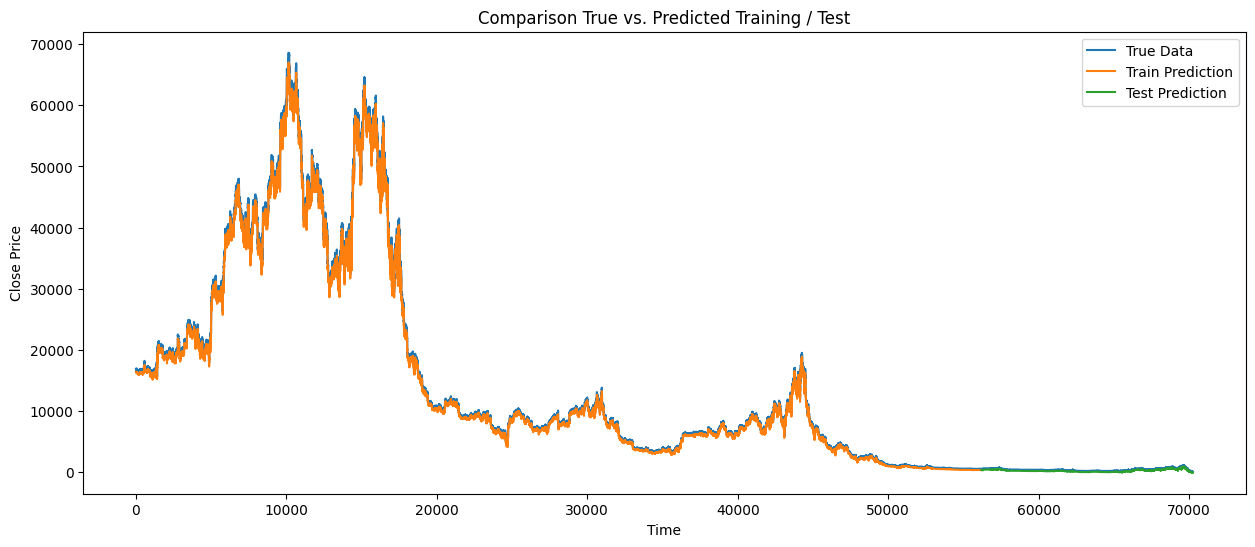

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('xbtusd_recent_100000.csv')

# Convert 'bucket' to datetime and set as index
df['bucket'] = pd.to_datetime(df['bucket'])
df.set_index('bucket', inplace=True)

# Select features to use for prediction
features = ['open_price', 'high', 'low', 'close_price', 'volume']
target = 'close_price'

# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[features])

# Split into training and test sets
train_size = int(len(scaled_data) * 0.80)
test_size = len(scaled_data) - train_size
train, test = scaled_data[0:train_size,:], scaled_data[train_size:len(scaled_data),:]

# Convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, features.index(target)])
    return np.array(X), np.array(Y)

look_back = 1
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(features)))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(features)))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, len(features))))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# Fit the model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=2)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform the predictions and the y values
# Create empty arrays with the same shape as 'scaled_data'
train_predictions = np.zeros(shape=(len(train_predict), scaled_data.shape[1]))
test_predictions = np.zeros(shape=(len(test_predict), scaled_data.shape[1]))

# Fill the predictions into the respective columns (assuming 'close_price' is the last column)
train_predictions[:, -1] = train_predict[:, 0]
test_predictions[:, -1] = test_predict[:, 0]

def inverse_transform_predictions(predictions, scaler, feature_index):
    # Create a dummy array with the same number of columns as the training data
    dummy = np.zeros((len(predictions), scaled_data.shape[1]))
    # Insert the predictions into the right column
    dummy[:, feature_index] = predictions[:, 0]
    # Inverse transform and then take the right column
    return scaler.inverse_transform(dummy)[:, feature_index]

# Inverse transform the predictions
train_predictions = inverse_transform_predictions(train_predict, scaler, features.index(target))
test_predictions = inverse_transform_predictions(test_predict, scaler, features.index(target))

# Inverse transform the original 'y_train' and 'y_test' if they were scaled
y_train_rescaled = inverse_transform_predictions(y_train.reshape(-1, 1), scaler, features.index(target))
y_test_rescaled = inverse_transform_predictions(y_test.reshape(-1, 1), scaler, features.index(target))

# Calculate root mean squared error
train_score = np.sqrt(np.mean((y_train_rescaled - train_predictions) ** 2))
test_score = np.sqrt(np.mean((y_test_rescaled - test_predictions) ** 2))
print(f'Train Score: {train_score:.2f} RMSE')
print(f'Test Score: {test_score:.2f} RMSE')

# Plot baseline and predictions
plt.figure(figsize=(15, 6))
plt.plot(df[target].values, label='True Data')
plt.plot(np.arange(look_back, len(train_predictions) + look_back), train_predictions, label='Train Prediction')
plt.plot(np.arange(len(train_predictions) + (look_back * 2) + 1, len(train_predictions) + (look_back * 2) + len(test_predictions) + 1), test_predictions, label='Test Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Comparison True vs. Predicted Training / Test')
plt.legend()
plt.show()


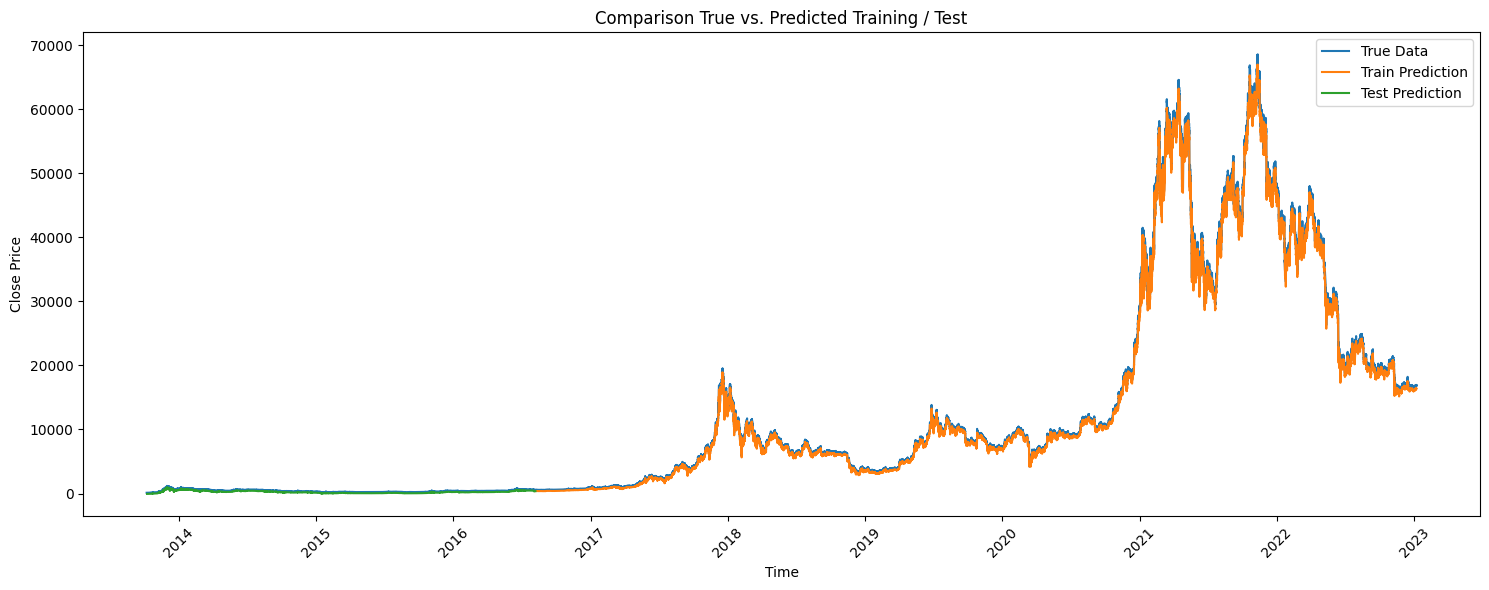

In [3]:
# Assuming 'df' still has the original timestamps and is indexed by them
timestamps = df.index.values

# Plot baseline and predictions with actual timestamps
plt.figure(figsize=(15, 6))

# Plot the actual data
plt.plot(timestamps, df[target].values, label='True Data')

# Generate timestamps for train predictions by taking the timestamps from the training set
train_timestamps = timestamps[look_back:len(train_predictions) + look_back]

# Plot the train predictions
plt.plot(train_timestamps, train_predictions, label='Train Prediction')

# Generate timestamps for test predictions by taking the timestamps from the test set
test_timestamps = timestamps[len(train_predictions) + (look_back * 2) + 1:len(scaled_data) - 1]

# Plot the test predictions
plt.plot(test_timestamps, test_predictions, label='Test Prediction')

plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Comparison True vs. Predicted Training / Test')
plt.legend()
plt.xticks(rotation=45)  # Rotate timestamps for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of timestamp labels
plt.show()

[0.23214129 0.23099137 0.23223939 0.23246392 0.00915682]
Epoch 1/10
1313/1313 - 5s - loss: 4.8894e-04 - 5s/epoch - 4ms/step
Epoch 2/10
1313/1313 - 4s - loss: 8.0755e-06 - 4s/epoch - 3ms/step
Epoch 3/10
1313/1313 - 4s - loss: 1.4057e-05 - 4s/epoch - 3ms/step
Epoch 4/10
1313/1313 - 4s - loss: 1.4763e-05 - 4s/epoch - 3ms/step
Epoch 5/10
1313/1313 - 4s - loss: 1.0052e-05 - 4s/epoch - 3ms/step
Epoch 6/10
1313/1313 - 3s - loss: 7.7743e-06 - 3s/epoch - 3ms/step
Epoch 7/10
1313/1313 - 3s - loss: 7.9734e-06 - 3s/epoch - 3ms/step
Epoch 8/10
1313/1313 - 3s - loss: 6.4362e-06 - 3s/epoch - 2ms/step
Epoch 9/10
1313/1313 - 3s - loss: 7.2450e-06 - 3s/epoch - 2ms/step
Epoch 10/10
1313/1313 - 3s - loss: 6.7187e-06 - 3s/epoch - 2ms/step
329/329 [==============================] - 1s 2ms/step
Train Score: 134.83 RMSE
Test Score: 89.58 RMSE


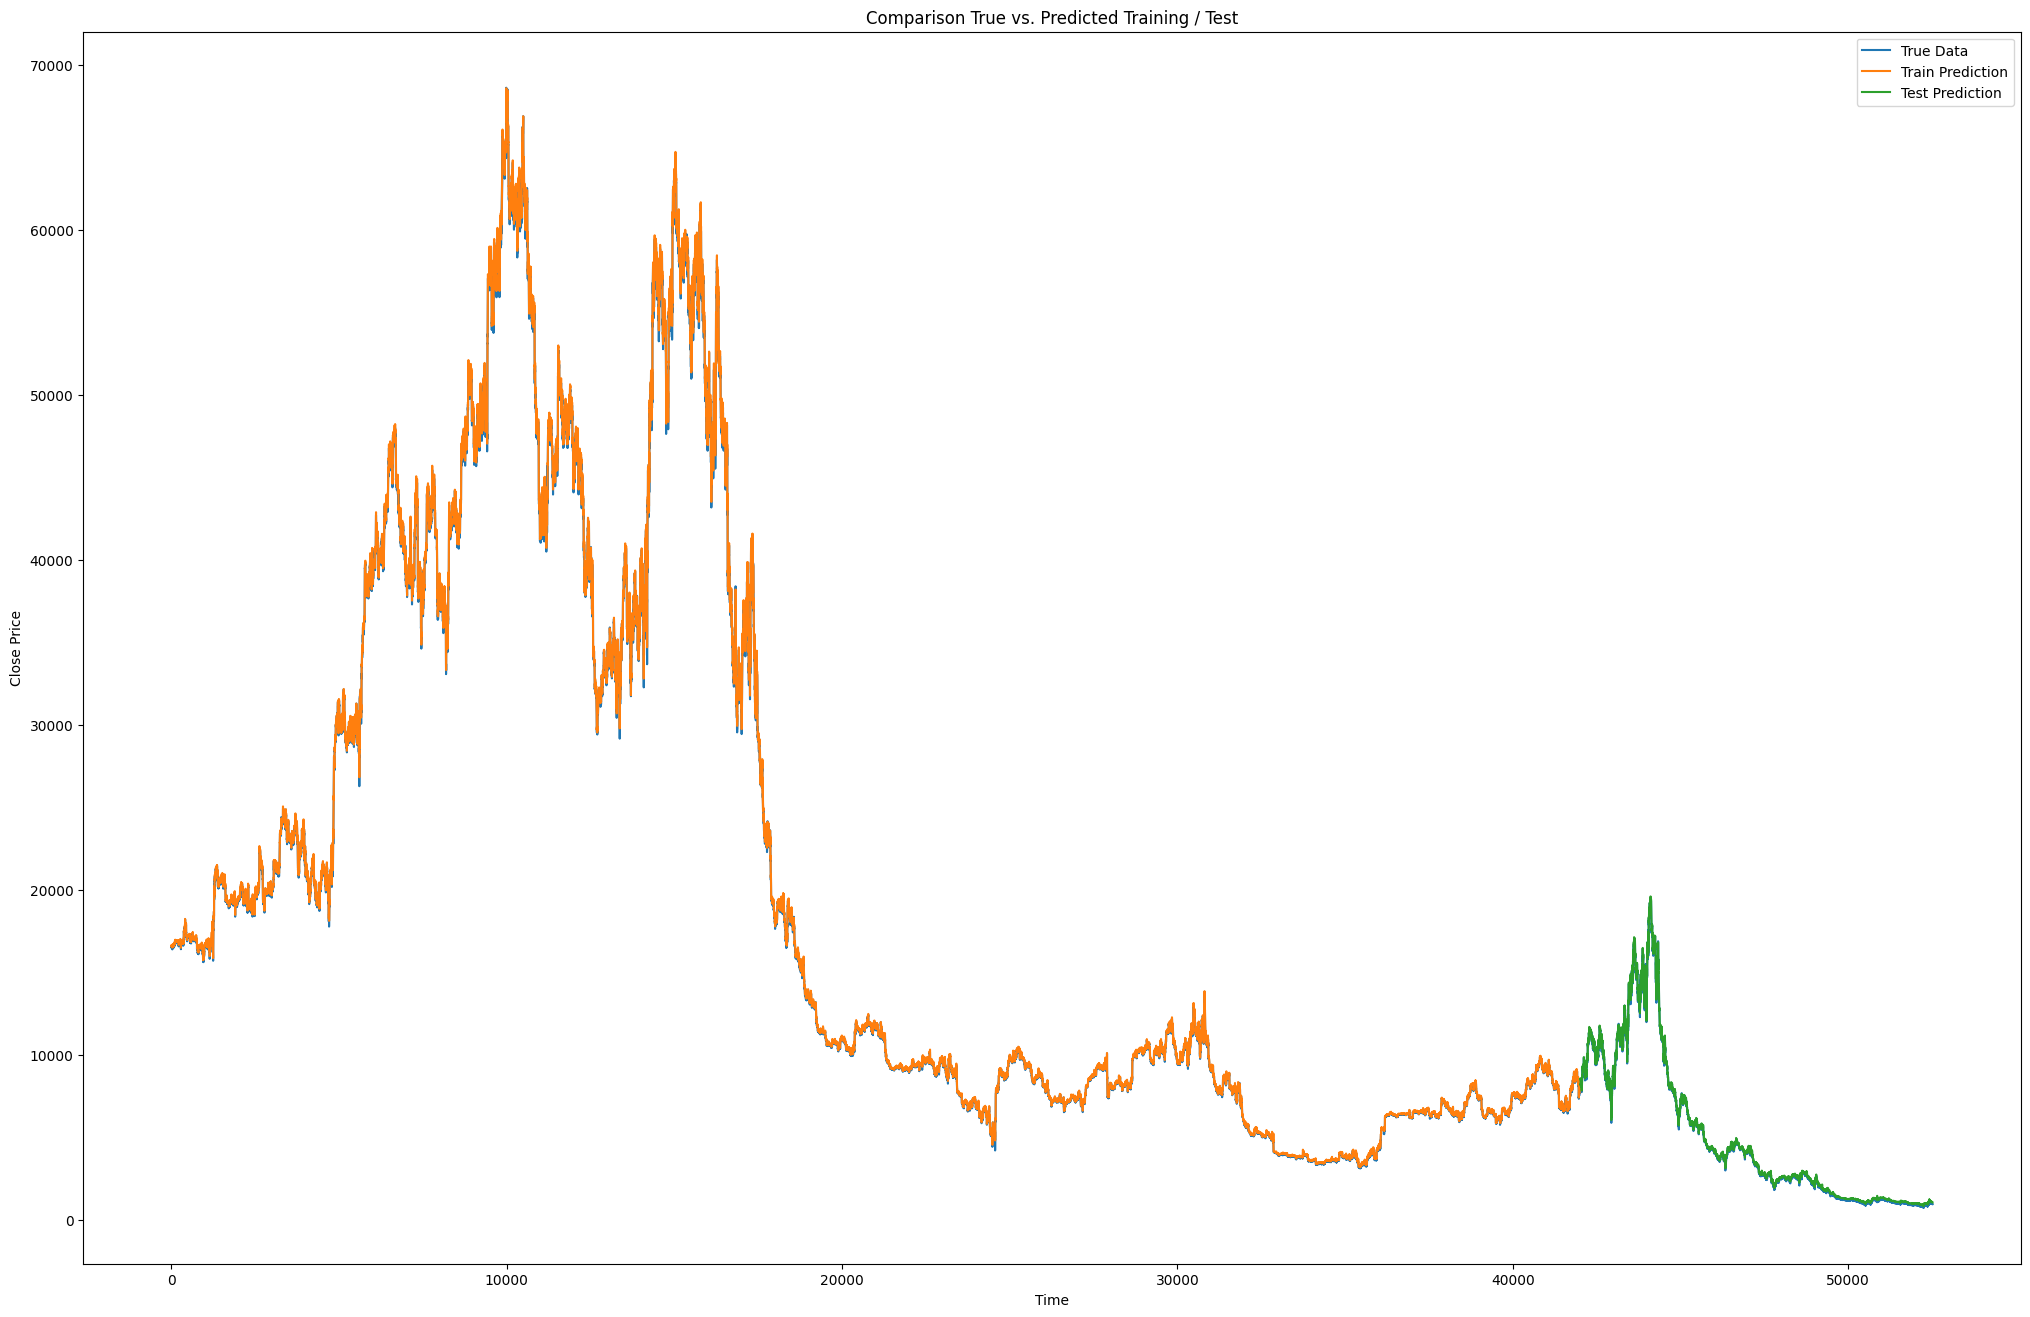

In [17]:
# XBTUSD-2017-2023

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('XBTUSD-2017-2023.csv')

# Convert 'bucket' to datetime and set as index
df['bucket'] = pd.to_datetime(df['bucket'])
df.set_index('bucket', inplace=True)

# Select features to use for prediction
features = ['open_price', 'high', 'low', 'close_price', 'volume']
target = 'close_price'

# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[features])

print(scaled_data[0])

# Split into training and test sets
train_size = int(len(scaled_data) * 0.80)
test_size = len(scaled_data) - train_size
train, test = scaled_data[0:train_size,:], scaled_data[train_size:len(scaled_data),:]

# Convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, features.index(target)])
    return np.array(X), np.array(Y)

look_back = 1
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(features)))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(features)))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, len(features))))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# Fit the model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=2)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform the predictions and the y values
# Create empty arrays with the same shape as 'scaled_data'
train_predictions = np.zeros(shape=(len(train_predict), scaled_data.shape[1]))
test_predictions = np.zeros(shape=(len(test_predict), scaled_data.shape[1]))

# Fill the predictions into the respective columns (assuming 'close_price' is the last column)
train_predictions[:, -1] = train_predict[:, 0]
test_predictions[:, -1] = test_predict[:, 0]

def inverse_transform_predictions(predictions, scaler, feature_index):
    # Create a dummy array with the same number of columns as the training data
    dummy = np.zeros((len(predictions), scaled_data.shape[1]))
    # Insert the predictions into the right column
    dummy[:, feature_index] = predictions[:, 0]
    # Inverse transform and then take the right column
    return scaler.inverse_transform(dummy)[:, feature_index]

# Inverse transform the predictions
train_predictions = inverse_transform_predictions(train_predict, scaler, features.index(target))
test_predictions = inverse_transform_predictions(test_predict, scaler, features.index(target))

# Inverse transform the original 'y_train' and 'y_test' if they were scaled
y_train_rescaled = inverse_transform_predictions(y_train.reshape(-1, 1), scaler, features.index(target))
y_test_rescaled = inverse_transform_predictions(y_test.reshape(-1, 1), scaler, features.index(target))

# Calculate root mean squared error
train_score = np.sqrt(np.mean((y_train_rescaled - train_predictions) ** 2))
test_score = np.sqrt(np.mean((y_test_rescaled - test_predictions) ** 2))
print(f'Train Score: {train_score:.2f} RMSE')
print(f'Test Score: {test_score:.2f} RMSE')

# Plot baseline and predictions
plt.figure(figsize=(25, 16))
plt.plot(df[target].values, label='True Data')
plt.plot(np.arange(look_back, len(train_predictions) + look_back), train_predictions, label='Train Prediction')
plt.plot(np.arange(len(train_predictions) + (look_back * 2) + 1, len(train_predictions) + (look_back * 2) + len(test_predictions) + 1), test_predictions, label='Test Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Comparison True vs. Predicted Training / Test')
plt.legend()
plt.show()


In [ ]:
# Plot baseline and predictions
plt.figure(figsize=(25, 16))
plt.plot(df[target].values, label='True Data')
plt.plot(np.arange(look_back, len(train_predictions) + look_back), train_predictions, label='Train Prediction')
plt.plot(np.arange(len(train_predictions) + (look_back * 2) + 1, len(train_predictions) + (look_back * 2) + len(test_predictions) + 1), test_predictions, label='Test Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Comparison True vs. Predicted Training / Test')
plt.legend()
plt.show()
